# ARMA Original Settings Reproduction — FIXED v2

# Synthetic ARMA Conditional Diffusion Experiment — Original Settings

This notebook is the GitHub/module version of the ARMA experiment from your original notebook.

The important point is that this notebook intentionally keeps the same ARMA data-generating process and training budget as the original:

- `T=8000`, `num_assets=5`, `sigma=0.01`, `corr=0.30`
- `context_length=24`
- LSTM hidden size `32`, `2` layers, dropout `0.1`
- U-Net base channels `32`, depth `1`
- `diffusion_steps=1000`
- `batch_size=256`, `epochs=300`
- generate `horizon=100`, `num_samples=2000`

The previous GitHub notebook used a smaller/faster configuration. That was useful for a quick demo, but it was **not** a faithful reproduction and can give much worse ARMA diagnostics.

In [2]:
cd /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from portfolio_diffusion import (
    DDPMConfig,
    TrainCfg,
    ConditionalRecurrentDDPM,
    build_dataloader,
    fit,
    seed_everything,
    simulate_arma_returns,
    generate_scenarios,
    arma_distribution_diagnostics,
    acf1_numpy_centered,
    acf1_torch_scenarios_centered,
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "arma_original_settings"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(42)
print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())

Project root: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model
Output dir: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings
CUDA available: True


## 1. Simulate ARMA returns

This is copied from the original experiment settings. No drift is added here, because the original ARMA diagnostic experiment focused on matching distributional moments and autocorrelation, not portfolio performance.

In [5]:
returns_raw = simulate_arma_returns(
    T=8000,
    num_assets=5,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.01,
    corr=0.30,
    seed=123,
)

asset_names = [f"Asset_{i+1}" for i in range(returns_raw.shape[1])]
dates = pd.period_range("1900-01", periods=len(returns_raw), freq="M")
returns_df = pd.DataFrame(returns_raw, index=dates, columns=asset_names)

print("Raw returns shape:", returns_raw.shape)
returns_df.head()

Raw returns shape: (8000, 5)


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5
1900-01,0.018119,0.011909,0.020040,0.011115,0.002253
1900-02,0.005785,-0.001633,0.019047,0.018856,0.003044
1900-03,0.003271,-0.000358,0.002877,0.016927,0.007592
1900-04,0.011028,-0.004003,-0.017875,0.010799,-0.011077
1900-05,0.010440,-0.002307,-0.013459,-0.014389,-0.012861


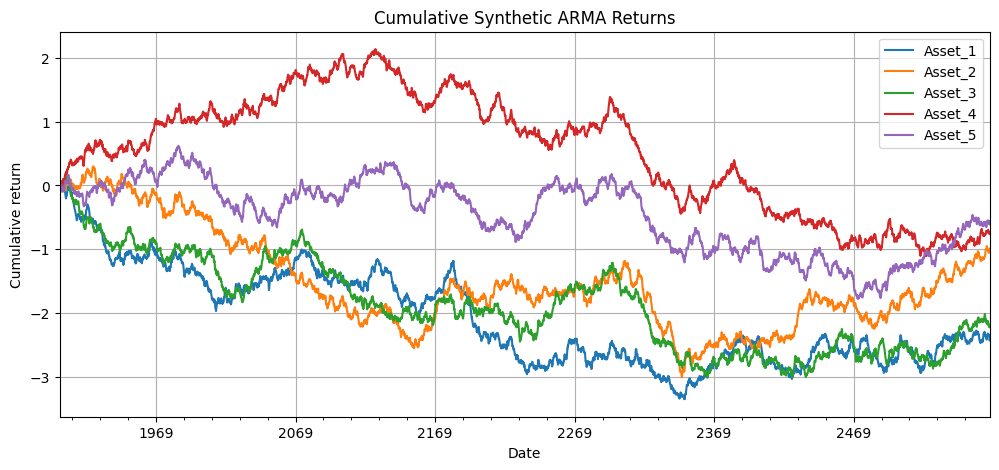

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
returns_df.cumsum().plot(ax=ax)
ax.set_title("Cumulative Synthetic ARMA Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.grid(True)
plt.show()

## 2. Configure DDPM model

These hyperparameters match the original notebook. The larger diffusion step count and longer training budget are important for reproducing the good ARMA result.

In [7]:
cfg = DDPMConfig(
    input_dim=returns_raw.shape[1],
    context_length=24,
    prediction_length=1,

    rnn_type="LSTM",
    rnn_hidden_dim=32,
    rnn_layers=2,
    rnn_dropout=0.1,

    unet_base_channels=32,
    unet_depth=1,
    time_embed_dim=128,

    diffusion_steps=1000,
    beta_start=1e-4,
    beta_end=2e-2,

    lr=2e-4,
    batch_size=256,
    epochs=300,
    grad_clip=1.0,
    weight_decay=1e-4,

    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)
print("Device:", device)
print(cfg)

Device: cuda
DDPMConfig(input_dim=5, context_length=24, prediction_length=1, rnn_type='LSTM', rnn_hidden_dim=32, rnn_layers=2, rnn_dropout=0.1, unet_base_channels=32, unet_depth=1, time_embed_dim=128, diffusion_steps=1000, beta_start=0.0001, beta_end=0.02, lr=0.0002, batch_size=256, epochs=300, grad_clip=1.0, weight_decay=0.0001, device='cuda', scale_condition=1.0)


In [8]:
# Sanity check: fail immediately if this notebook is not using the original ARMA settings.
assert returns_raw.shape == (8000, 5), returns_raw.shape
assert cfg.context_length == 24
assert cfg.prediction_length == 1
assert cfg.rnn_hidden_dim == 32
assert cfg.rnn_layers == 2
assert abs(cfg.rnn_dropout - 0.1) < 1e-12
assert cfg.unet_base_channels == 32
assert cfg.unet_depth == 1
assert cfg.diffusion_steps == 1000
assert cfg.batch_size == 256
assert cfg.epochs == 300
print("ARMA original settings sanity check passed.")

ARMA original settings sanity check passed.


## 3. Train/validation split and standardization

This follows the original split exactly: first 80% for training; validation includes a context overlap.

In [9]:
split_idx = int(0.80 * len(returns_raw))

train_raw = returns_raw[:split_idx]

# Validation needs context overlap, same as the original notebook.
valid_raw = returns_raw[split_idx - cfg.context_length:]
valid_dates = dates[split_idx - cfg.context_length:]

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True) + 1e-8

train_returns = (train_raw - mean) / std
valid_returns = (valid_raw - mean) / std

print("Train returns mean:", train_returns.mean(axis=0))
print("Train returns std:", train_returns.std(axis=0))
print("Train raw shape:", train_raw.shape)
print("Valid raw with context shape:", valid_raw.shape)

Train returns mean: [-1.0474585e-07 -5.0812961e-08 -4.8112124e-08 -3.4564291e-08
 -1.6689301e-08]
Train returns std: [0.99999815 0.999998   0.9999982  0.9999983  0.9999989 ]
Train raw shape: (6400, 5)
Valid raw with context shape: (1624, 5)


## 4. Dataloaders

The package uses the repo-style sequence-to-sequence target shape:

```text
context: [B, 24, 5]
target:  [B, 24, 1, 5]
```

So each RNN hidden state gets its own diffusion loss.

In [10]:
train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

batch = next(iter(train_loader))
print("context shape:", batch["context"].shape)
print("target shape:", batch["target"].shape)

Train samples: 6376
Valid samples: 1600
context shape: torch.Size([256, 24, 5])
target shape: torch.Size([256, 24, 1, 5])


## 5. Train

This uses the same training budget as your original successful ARMA notebook. On CPU this can be slow; on Colab GPU it is the setting that produced the good ACF/std matching.

In [11]:
model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=2e-4,
    weight_decay=1e-4,
    scheduler="cosine",
    num_epochs=300,

    use_ema=True,
    ema_decay=0.999,

    max_grad_norm=1.0,
    amp=torch.cuda.is_available(),
    patience=40,

    seed=42,
    save_path=str(OUTPUT_DIR / "best_arma_return_ddpm.pt"),
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
history_df.tail()

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/300:   0%|          | 0/24 [00:00<?, ?it/s]/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/300] train=0.544994 val=1.173305 lr=2.00e-04 t=0.0m


[002/300] train=0.299214 val=1.115814 lr=2.00e-04 t=0.1m


[003/300] train=0.277161 val=1.065772 lr=2.00e-04 t=0.1m


[004/300] train=0.270544 val=1.021708 lr=2.00e-04 t=0.1m


...

[238/300] train=0.235750 val=0.241535 lr=2.93e-05 t=5.9m


[239/300] train=0.235849 val=0.242918 lr=2.87e-05 t=6.0m


[240/300] train=0.234863 val=0.241006 lr=2.81e-05 t=6.0m


[241/300] train=0.236579 val=0.238708 lr=2.76e-05 t=6.0m
Early stopping


,train_loss,val_loss,lr
236,0.235767,0.240853,0.000030
237,0.235750,0.241535,0.000029
238,0.235849,0.242918,0.000029
239,0.234863,0.241006,0.000028
240,0.236579,0.238708,0.000028


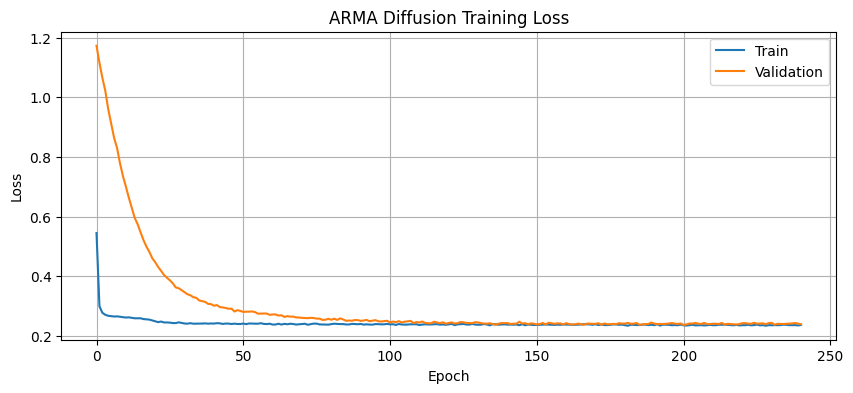

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_df.index, history_df["train_loss"], label="Train")
ax.plot(history_df.index, history_df["val_loss"], label="Validation")
ax.set_title("ARMA Diffusion Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)
plt.show()

## 6. Generate return scenarios

This matches the original diagnostic generation: use the last validation window, generate 100 future steps, and create 2000 paths.

In [16]:
# Sanity check for the original diagnostic generation settings.
ARMA_DIAGNOSTIC_HORIZON = 100
ARMA_DIAGNOSTIC_NUM_SAMPLES = 2000
assert ARMA_DIAGNOSTIC_HORIZON == 100
assert ARMA_DIAGNOSTIC_NUM_SAMPLES == 2000
print("Generation sanity check passed:", ARMA_DIAGNOSTIC_HORIZON, ARMA_DIAGNOSTIC_NUM_SAMPLES)

Generation sanity check passed: 100 2000


In [17]:
history_window = valid_returns[-cfg.context_length:]

scenarios = generate_scenarios(
    model=best_model,
    return_history_window=history_window,
    horizon=ARMA_DIAGNOSTIC_HORIZON,
    num_samples=ARMA_DIAGNOSTIC_NUM_SAMPLES,
    eta=1.0,
    clip_x0=None,
)

generated_returns_standardized = scenarios["returns"].detach().cpu()
generated_rnn_features = scenarios["features"].detach().cpu()

print("Generated standardized returns:")
print(generated_returns_standardized.shape)
print("Generated RNN features:")
print(generated_rnn_features.shape)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Generated standardized returns:
torch.Size([100, 2000, 5])
Generated RNN features:
torch.Size([100, 2000, 32])


In [18]:
mean_t = torch.as_tensor(mean, dtype=torch.float32).view(1, 1, -1)
std_t = torch.as_tensor(std, dtype=torch.float32).view(1, 1, -1)

generated_returns_raw = generated_returns_standardized * std_t + mean_t

print("Generated raw returns:")
print(generated_returns_raw.shape)

Generated raw returns:
torch.Size([100, 2000, 5])


## 7. Original distribution diagnostics

These are the same diagnostics used in your uploaded ARMA notebook: standardized mean, standardized standard deviation, and centered lag-1 autocorrelation.

In [19]:
real_mean = valid_returns.mean(axis=0)
real_std = valid_returns.std(axis=0)
real_acf1 = acf1_numpy_centered(valid_returns)

gen_flat = generated_returns_standardized.reshape(
    -1,
    generated_returns_standardized.shape[-1],
)

gen_mean = gen_flat.mean(dim=0)
gen_std = gen_flat.std(dim=0)
gen_acf1 = acf1_torch_scenarios_centered(generated_returns_standardized)

print("Real standardized mean:", real_mean)
print("Gen standardized mean: ", gen_mean)

print("Real standardized std:", real_std)
print("Gen standardized std: ", gen_std)

print("Real centered ACF1:", real_acf1)
print("Gen centered ACF1: ", gen_acf1)

Real standardized mean: [ 0.06368026  0.07070778  0.07028411 -0.00164474  0.05836476]
Gen standardized mean:  tensor([0.0094, 0.0111, 0.0081, 0.0225, 0.0092])
Real standardized std: [0.9940831  0.97487223 1.0457773  0.96594363 0.99727076]
Gen standardized std:  tensor([0.9857, 0.9882, 0.9895, 0.9894, 0.9900])
Real centered ACF1: [0.51871604 0.51400393 0.5341149  0.5372007  0.53883725]
Gen centered ACF1:  tensor([0.5173, 0.5330, 0.5180, 0.4978, 0.5168])


In [20]:
diagnostics_df, diagnostics_summary = arma_distribution_diagnostics(
    real_standardized=valid_returns,
    generated_standardized=generated_returns_standardized,
    asset_names=asset_names,
)

print("Summary metrics:")
for k, v in diagnostics_summary.items():
    print(f"{k}: {v:.6f}")

diagnostics_df.to_csv(OUTPUT_DIR / "arma_distribution_diagnostics.csv", index=False)
pd.Series(diagnostics_summary).to_csv(OUTPUT_DIR / "arma_distribution_diagnostics_summary.csv")
diagnostics_df

Summary metrics:
Mean MAE: 0.049858
Std MAE: 0.021762
ACF1 MAE: 0.019592


,asset,real_mean,gen_mean,abs_mean_error,real_std,gen_std,abs_std_error,real_acf1,gen_acf1,abs_acf1_error
0,Asset_1,0.063680,0.009436,0.054245,0.994083,0.985676,0.008407,0.518716,0.517262,0.001454
1,Asset_2,0.070708,0.011134,0.059574,0.974872,0.988191,0.013319,0.514004,0.533021,0.019017
2,Asset_3,0.070284,0.008091,0.062193,1.045777,0.989457,0.056320,0.534115,0.518015,0.016100
3,Asset_4,-0.001645,0.022452,0.024097,0.965944,0.989434,0.023490,0.537201,0.497798,0.039402
4,Asset_5,0.058365,0.009183,0.049182,0.997271,0.989996,0.007275,0.538837,0.516849,0.021988


## 8. Diagnostic plots

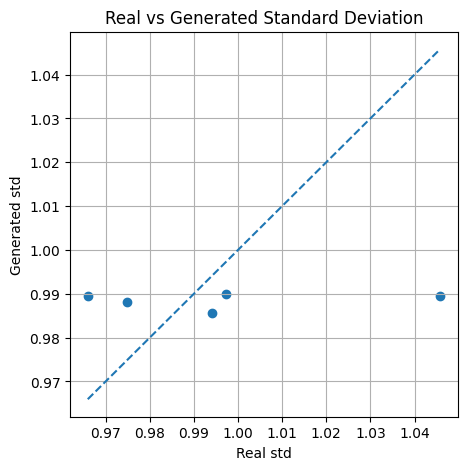

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(diagnostics_df["real_std"], diagnostics_df["gen_std"])
lo = min(diagnostics_df["real_std"].min(), diagnostics_df["gen_std"].min())
hi = max(diagnostics_df["real_std"].max(), diagnostics_df["gen_std"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_title("Real vs Generated Standard Deviation")
ax.set_xlabel("Real std")
ax.set_ylabel("Generated std")
ax.grid(True)
plt.show()

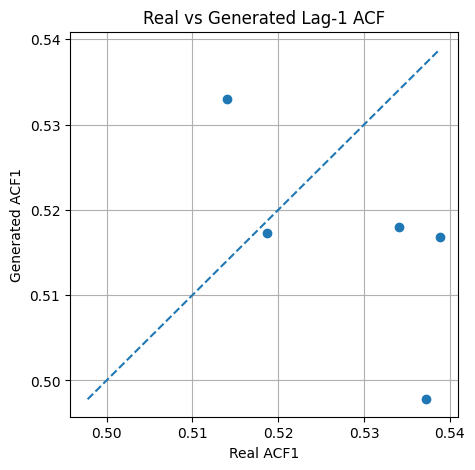

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(diagnostics_df["real_acf1"], diagnostics_df["gen_acf1"])
lo = min(diagnostics_df["real_acf1"].min(), diagnostics_df["gen_acf1"].min())
hi = max(diagnostics_df["real_acf1"].max(), diagnostics_df["gen_acf1"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_title("Real vs Generated Lag-1 ACF")
ax.set_xlabel("Real ACF1")
ax.set_ylabel("Generated ACF1")
ax.grid(True)
plt.show()

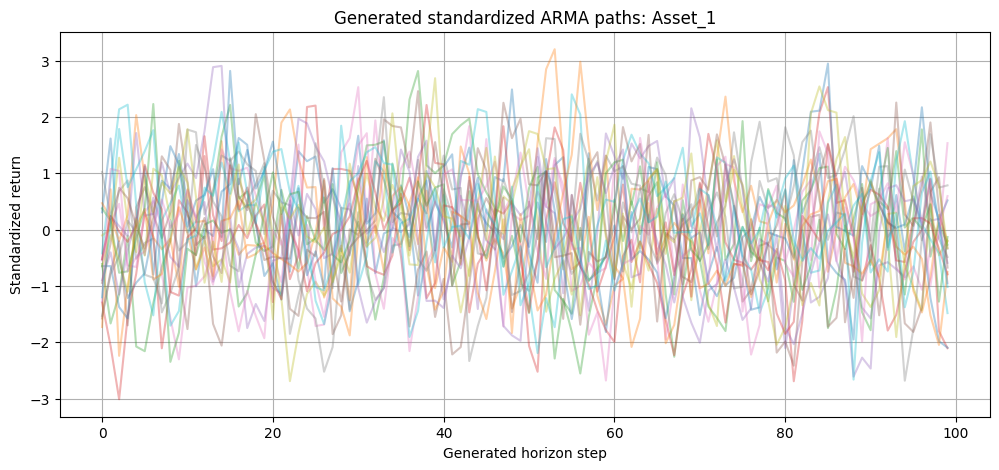

In [23]:
asset_idx = 0
asset_name = asset_names[asset_idx]

fig, ax = plt.subplots(figsize=(12, 5))
for sample_id in range(20):
    ax.plot(generated_returns_standardized[:, sample_id, asset_idx].numpy(), alpha=0.35)
ax.set_title(f"Generated standardized ARMA paths: {asset_name}")
ax.set_xlabel("Generated horizon step")
ax.set_ylabel("Standardized return")
ax.grid(True)
plt.show()

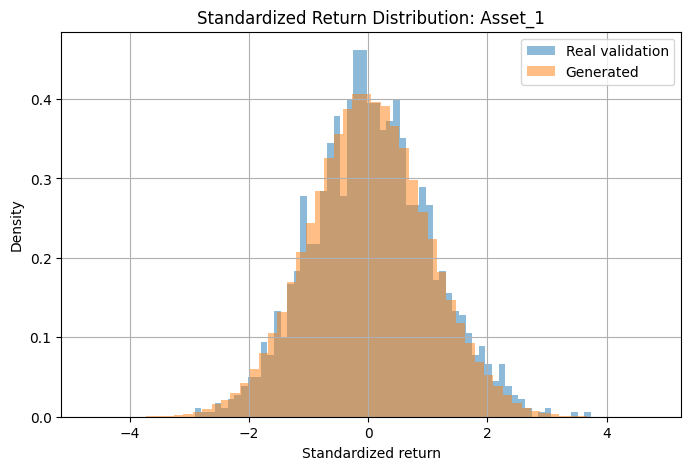

In [24]:
asset_idx = 0
asset_name = asset_names[asset_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_returns[:, asset_idx], bins=60, alpha=0.50, density=True, label="Real validation")
ax.hist(generated_returns_standardized[:, :, asset_idx].reshape(-1).numpy(), bins=60, alpha=0.50, density=True, label="Generated")
ax.set_title(f"Standardized Return Distribution: {asset_name}")
ax.set_xlabel("Standardized return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)
plt.show()

In [25]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. Helper: convert generated tensor to [H, S, D]
# ============================================================

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def ensure_horizon_sample_asset(x, horizon=None):
    """
    Ensures shape is [horizon, num_samples, num_assets].
    Your generated data may be [H, S, D] or [S, H, D].
    """
    x = to_numpy(x)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape}")

    if horizon is None:
        # assume first dim is horizon
        return x

    if x.shape[0] == horizon:
        return x

    if x.shape[1] == horizon:
        return np.transpose(x, (1, 0, 2))

    raise ValueError(
        f"Cannot infer horizon axis. Got shape {x.shape}, horizon={horizon}"
    )


H = ARMA_DIAGNOSTIC_HORIZON
S = ARMA_DIAGNOSTIC_NUM_SAMPLES

generated_std = ensure_horizon_sample_asset(
    generated_returns_standardized,
    horizon=H,
)

H, S, D = generated_std.shape

print("Generated standardized shape [H, S, D]:", generated_std.shape)

Generated standardized shape [H, S, D]: (100, 2000, 5)


In [26]:
# ============================================================
# 2. Conditional ARMA simulation from the same context
# ============================================================

ARMA_AR = (0.35,)
ARMA_MA = (0.25,)
ARMA_SIGMA = 0.01
ARMA_CORR = 0.30
ARMA_SEED = 999


def estimate_arma_innovations_from_history(history_raw, ar=(0.35,), ma=(0.25,)):
    """
    Estimate eps_t recursively from observed ARMA history.

    history_raw: [context_length, num_assets]
    """
    history_raw = np.asarray(history_raw, dtype=np.float64)

    L, D = history_raw.shape
    eps_hat = np.zeros_like(history_raw)

    for t in range(L):
        ar_part = np.zeros(D)
        ma_part = np.zeros(D)

        for i, phi in enumerate(ar, start=1):
            if t - i >= 0:
                ar_part += phi * history_raw[t - i]

        for j, theta in enumerate(ma, start=1):
            if t - j >= 0:
                ma_part += theta * eps_hat[t - j]

        eps_hat[t] = history_raw[t] - ar_part - ma_part

    return eps_hat


def simulate_conditional_arma_paths(
    history_raw,
    horizon,
    num_samples,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.01,
    corr=0.30,
    seed=999,
):
    """
    Simulate conditional ARMA paths from the exact same history window.

    Returns:
        simulated_raw: [horizon, num_samples, num_assets]
    """
    rng = np.random.default_rng(seed)

    history_raw = np.asarray(history_raw, dtype=np.float64)
    L, D = history_raw.shape

    p = len(ar)
    q = len(ma)

    cov = np.full((D, D), corr * sigma**2)
    np.fill_diagonal(cov, sigma**2)

    eps_hist = estimate_arma_innovations_from_history(history_raw, ar=ar, ma=ma)

    simulated = np.zeros((horizon, num_samples, D), dtype=np.float64)

    for s in range(num_samples):
        r_lags = [history_raw[-i].copy() for i in range(1, p + 1)]
        eps_lags = [eps_hist[-j].copy() for j in range(1, q + 1)]

        for h in range(horizon):
            eps_t = rng.multivariate_normal(
                mean=np.zeros(D),
                cov=cov,
            )

            ar_part = np.zeros(D)
            ma_part = np.zeros(D)

            for i, phi in enumerate(ar):
                ar_part += phi * r_lags[i]

            for j, theta in enumerate(ma):
                ma_part += theta * eps_lags[j]

            r_t = ar_part + eps_t + ma_part

            simulated[h, s] = r_t

            if p > 0:
                r_lags = [r_t.copy()] + r_lags[:-1]

            if q > 0:
                eps_lags = [eps_t.copy()] + eps_lags[:-1]

    return simulated


# ------------------------------------------------------------
# Get same context window in raw scale
# ------------------------------------------------------------

mean_vec = np.asarray(mean).reshape(-1)
std_vec = np.asarray(std).reshape(-1)

history_window_std = np.asarray(history_window, dtype=np.float64)

# If you have valid_raw, use it directly.
# Otherwise unstandardize the standardized history window.
try:
    history_window_raw = valid_raw[-cfg.context_length:]
except NameError:
    history_window_raw = history_window_std * std_vec.reshape(1, -1) + mean_vec.reshape(1, -1)

print("History raw shape:", history_window_raw.shape)

# ------------------------------------------------------------
# Simulate true ARMA paths from same history
# ------------------------------------------------------------

simulated_raw = simulate_conditional_arma_paths(
    history_raw=history_window_raw,
    horizon=H,
    num_samples=S,
    ar=ARMA_AR,
    ma=ARMA_MA,
    sigma=ARMA_SIGMA,
    corr=ARMA_CORR,
    seed=ARMA_SEED,
)

simulated_std = (
    simulated_raw - mean_vec.reshape(1, 1, -1)
) / std_vec.reshape(1, 1, -1)

print("Simulated raw shape:", simulated_raw.shape)
print("Simulated standardized shape:", simulated_std.shape)

History raw shape: (24, 5)
Simulated raw shape: (100, 2000, 5)
Simulated standardized shape: (100, 2000, 5)


In [27]:
# ============================================================
# 3. Distribution diagnostics
# ============================================================

def acf1_scenarios_centered(x):
    """
    x: [H, S, D]
    """
    x = np.asarray(x, dtype=np.float64)
    x_centered = x - x.mean(axis=(0, 1), keepdims=True)

    num = (x_centered[:-1] * x_centered[1:]).mean(axis=(0, 1))
    den = (x_centered * x_centered).mean(axis=(0, 1)) + 1e-8

    return num / den


def scenario_stats(x):
    """
    x: [H, S, D]
    """
    x = np.asarray(x, dtype=np.float64)
    flat = x.reshape(-1, x.shape[-1])

    return {
        "mean": flat.mean(axis=0),
        "std": flat.std(axis=0),
        "acf1": acf1_scenarios_centered(x),
        "q025": np.quantile(flat, 0.025, axis=0),
        "q500": np.quantile(flat, 0.500, axis=0),
        "q975": np.quantile(flat, 0.975, axis=0),
    }


gen_stats = scenario_stats(generated_std)
sim_stats = scenario_stats(simulated_std)

asset_names = [f"Asset_{i+1}" for i in range(D)]

diagnostics_df = pd.DataFrame({
    "asset": asset_names,

    "sim_mean": sim_stats["mean"],
    "gen_mean": gen_stats["mean"],
    "abs_mean_error": np.abs(sim_stats["mean"] - gen_stats["mean"]),

    "sim_std": sim_stats["std"],
    "gen_std": gen_stats["std"],
    "abs_std_error": np.abs(sim_stats["std"] - gen_stats["std"]),

    "sim_acf1": sim_stats["acf1"],
    "gen_acf1": gen_stats["acf1"],
    "abs_acf1_error": np.abs(sim_stats["acf1"] - gen_stats["acf1"]),

    "sim_q025": sim_stats["q025"],
    "gen_q025": gen_stats["q025"],
    "abs_q025_error": np.abs(sim_stats["q025"] - gen_stats["q025"]),

    "sim_q975": sim_stats["q975"],
    "gen_q975": gen_stats["q975"],
    "abs_q975_error": np.abs(sim_stats["q975"] - gen_stats["q975"]),
})

summary = {
    "Mean MAE": diagnostics_df["abs_mean_error"].mean(),
    "Std MAE": diagnostics_df["abs_std_error"].mean(),
    "ACF1 MAE": diagnostics_df["abs_acf1_error"].mean(),
    "Q025 MAE": diagnostics_df["abs_q025_error"].mean(),
    "Q975 MAE": diagnostics_df["abs_q975_error"].mean(),
}

print("Generated vs conditional simulated ARMA diagnostics:")
for k, v in summary.items():
    print(f"{k}: {v:.6f}")

diagnostics_df

Generated vs conditional simulated ARMA diagnostics:
Mean MAE: 0.021563
Std MAE: 0.011922
ACF1 MAE: 0.011518
Q025 MAE: 0.026226
Q975 MAE: 0.039526


,asset,sim_mean,gen_mean,abs_mean_error,sim_std,gen_std,abs_std_error,sim_acf1,gen_acf1,abs_acf1_error,sim_q025,gen_q025,abs_q025_error,sim_q975,gen_q975,abs_q975_error
0,Asset_1,0.029559,0.009436,0.020123,0.990398,0.985674,0.004725,0.528109,0.517262,0.010847,-1.918234,-1.926555,0.008320,1.974800,1.961299,0.013501
1,Asset_2,0.026129,0.011134,0.014995,0.978061,0.988188,0.010127,0.528315,0.533021,0.004707,-1.893271,-1.948235,0.054963,1.942402,1.971925,0.029524
2,Asset_3,0.041530,0.008091,0.033439,1.007810,0.989455,0.018355,0.523199,0.518015,0.005184,-1.935728,-1.949806,0.014078,2.021156,1.916008,0.105148
3,Asset_4,0.009469,0.022452,0.012983,1.005014,0.989432,0.015582,0.527318,0.497798,0.029520,-1.962007,-1.928954,0.033053,1.976909,1.961483,0.015426
4,Asset_5,0.035454,0.009183,0.026272,1.000813,0.989994,0.010819,0.524181,0.516849,0.007332,-1.919239,-1.898522,0.020717,2.004185,1.970153,0.034032


In [28]:
# ============================================================
# 4. Cross-sectional correlation matrices
# ============================================================

def cross_section_corr_matrix(x):
    """
    x: [H, S, D]
    Returns correlation matrix across assets: [D, D]
    """
    x = np.asarray(x, dtype=np.float64)
    flat = x.reshape(-1, x.shape[-1])
    return np.corrcoef(flat, rowvar=False)


def offdiag_mae(a, b):
    mask = ~np.eye(a.shape[0], dtype=bool)
    return np.mean(np.abs(a[mask] - b[mask]))


gen_corr = cross_section_corr_matrix(generated_std)
sim_corr = cross_section_corr_matrix(simulated_std)

corr_error = gen_corr - sim_corr
corr_mae = offdiag_mae(gen_corr, sim_corr)

print("Generated cross-sectional correlation:")
print(pd.DataFrame(gen_corr, index=asset_names, columns=asset_names))

print("\nSimulated ARMA cross-sectional correlation:")
print(pd.DataFrame(sim_corr, index=asset_names, columns=asset_names))

print(f"\nOff-diagonal correlation MAE: {corr_mae:.6f}")

Generated cross-sectional correlation:
          Asset_1   Asset_2   Asset_3   Asset_4   Asset_5
Asset_1  1.000000  0.320673  0.309726  0.315332  0.313991
Asset_2  0.320673  1.000000  0.329125  0.300567  0.301037
Asset_3  0.309726  0.329125  1.000000  0.299585  0.311937
Asset_4  0.315332  0.300567  0.299585  1.000000  0.303338
Asset_5  0.313991  0.301037  0.311937  0.303338  1.000000

Simulated ARMA cross-sectional correlation:
          Asset_1   Asset_2   Asset_3   Asset_4   Asset_5
Asset_1  1.000000  0.298952  0.298897  0.299535  0.294229
Asset_2  0.298952  1.000000  0.303971  0.300140  0.298208
Asset_3  0.298897  0.303971  1.000000  0.302294  0.305753
Asset_4  0.299535  0.300140  0.302294  1.000000  0.295512
Asset_5  0.294229  0.298208  0.305753  0.295512  1.000000

Off-diagonal correlation MAE: 0.011324


/tmp/ipykernel_1055/1072776260.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


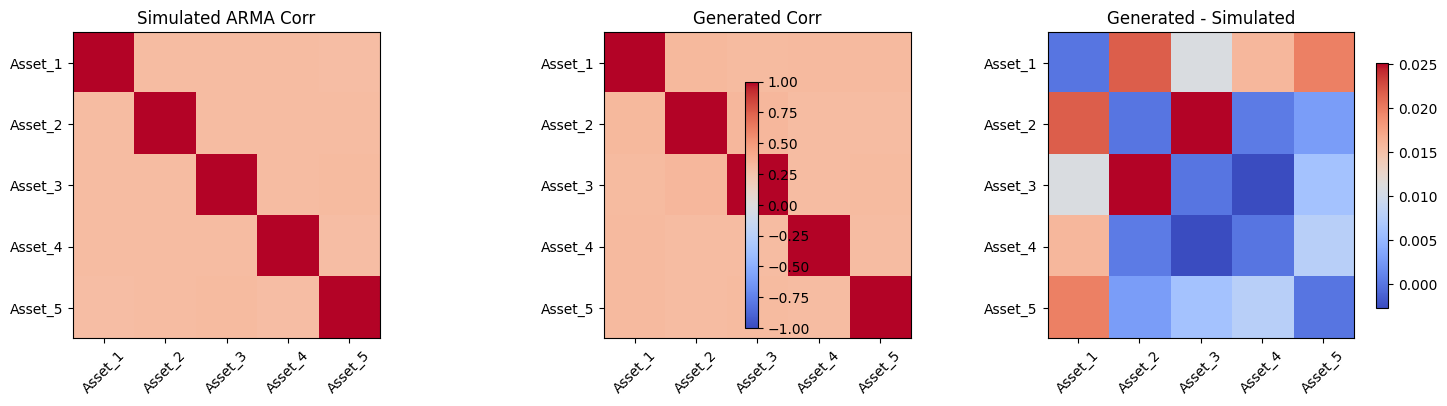

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(sim_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Simulated ARMA Corr")
axes[0].set_xticks(range(D))
axes[0].set_yticks(range(D))
axes[0].set_xticklabels(asset_names, rotation=45)
axes[0].set_yticklabels(asset_names)

im1 = axes[1].imshow(gen_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Generated Corr")
axes[1].set_xticks(range(D))
axes[1].set_yticks(range(D))
axes[1].set_xticklabels(asset_names, rotation=45)
axes[1].set_yticklabels(asset_names)

im2 = axes[2].imshow(corr_error, cmap="coolwarm")
axes[2].set_title("Generated - Simulated")
axes[2].set_xticks(range(D))
axes[2].set_yticks(range(D))
axes[2].set_xticklabels(asset_names, rotation=45)
axes[2].set_yticklabels(asset_names)

fig.colorbar(im0, ax=axes[:2], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 5. Plot 95% price range for generated and simulated paths
# ============================================================

def returns_to_price_paths(returns, initial_price=100.0):
    """
    Convert return paths to price paths.

    returns: [H, S, D]
        H = horizon
        S = number of scenarios
        D = number of assets

    returns:
        prices: [H + 1, S, D]
        Includes initial price at time 0.
    """
    returns = np.asarray(returns, dtype=np.float64)

    H, S, D = returns.shape

    prices = np.empty((H + 1, S, D), dtype=np.float64)
    prices[0] = initial_price

    prices[1:] = initial_price * np.cumprod(1.0 + returns, axis=0)

    return prices


def plot_95_price_bands(
    generated_returns,
    simulated_returns,
    asset_names=None,
    initial_price=100.0,
    scale_name="raw returns",
):
    """
    Plot 95% price/wealth bands implied by return scenarios.

    generated_returns: [H, S, D]
    simulated_returns: [H, S, D]
    """
    generated_returns = np.asarray(generated_returns, dtype=np.float64)
    simulated_returns = np.asarray(simulated_returns, dtype=np.float64)

    H, S, D = generated_returns.shape

    if asset_names is None:
        asset_names = [f"Asset_{i+1}" for i in range(D)]

    generated_prices = returns_to_price_paths(
        generated_returns,
        initial_price=initial_price,
    )

    simulated_prices = returns_to_price_paths(
        simulated_returns,
        initial_price=initial_price,
    )

    x_axis = np.arange(H + 1)

    gen_mean = generated_prices.mean(axis=1)
    gen_low = np.quantile(generated_prices, 0.025, axis=1)
    gen_high = np.quantile(generated_prices, 0.975, axis=1)

    sim_mean = simulated_prices.mean(axis=1)
    sim_low = np.quantile(simulated_prices, 0.025, axis=1)
    sim_high = np.quantile(simulated_prices, 0.975, axis=1)

    for j in range(D):
        plt.figure(figsize=(11, 5))

        plt.fill_between(
            x_axis,
            sim_low[:, j],
            sim_high[:, j],
            alpha=0.25,
            label="Simulated ARMA 95% price range",
        )

        plt.fill_between(
            x_axis,
            gen_low[:, j],
            gen_high[:, j],
            alpha=0.25,
            label="Generated diffusion 95% price range",
        )

        plt.plot(
            x_axis,
            sim_mean[:, j],
            linewidth=2,
            label="Simulated ARMA mean price",
        )

        plt.plot(
            x_axis,
            gen_mean[:, j],
            linewidth=2,
            linestyle="--",
            label="Generated diffusion mean price",
        )

        plt.axhline(initial_price, linewidth=1)

        plt.title(f"{asset_names[j]}: 95% Price Range from Return Scenarios")
        plt.xlabel("Forecast horizon")
        plt.ylabel(f"Price index, initial={initial_price}")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "generated_prices": generated_prices,
        "simulated_prices": simulated_prices,
        "generated_price_mean": gen_mean,
        "generated_price_low": gen_low,
        "generated_price_high": gen_high,
        "simulated_price_mean": sim_mean,
        "simulated_price_low": sim_low,
        "simulated_price_high": sim_high,
    }

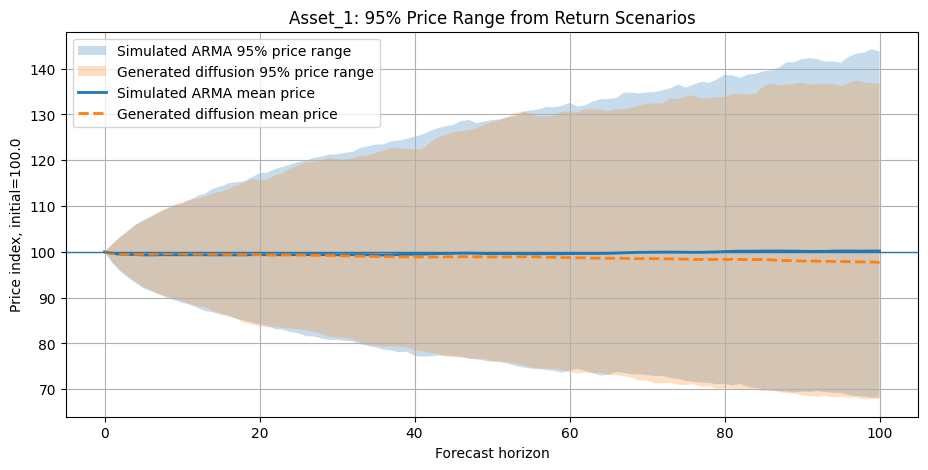

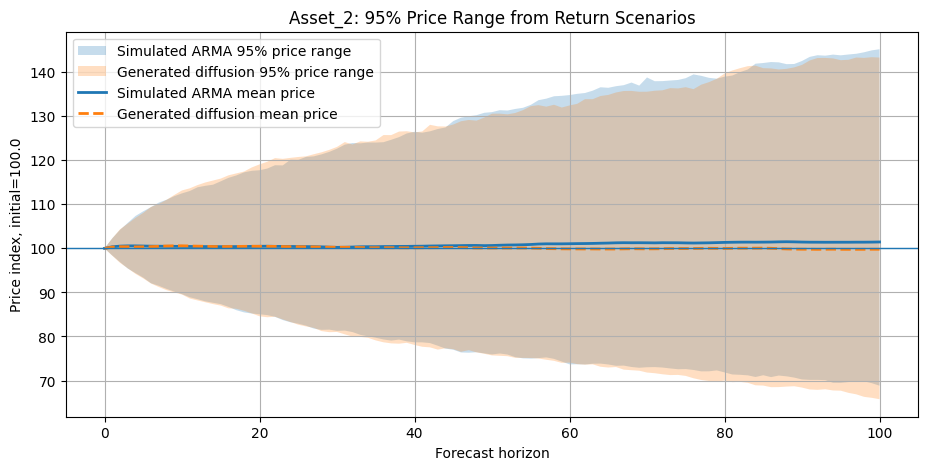

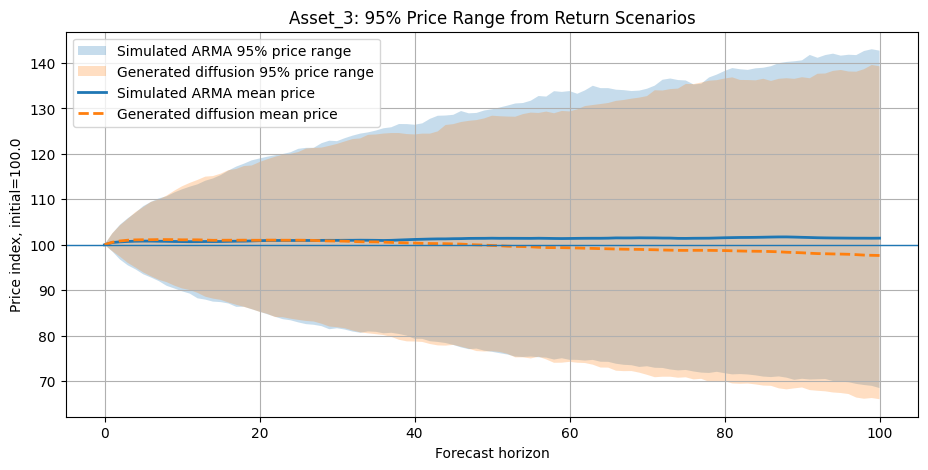

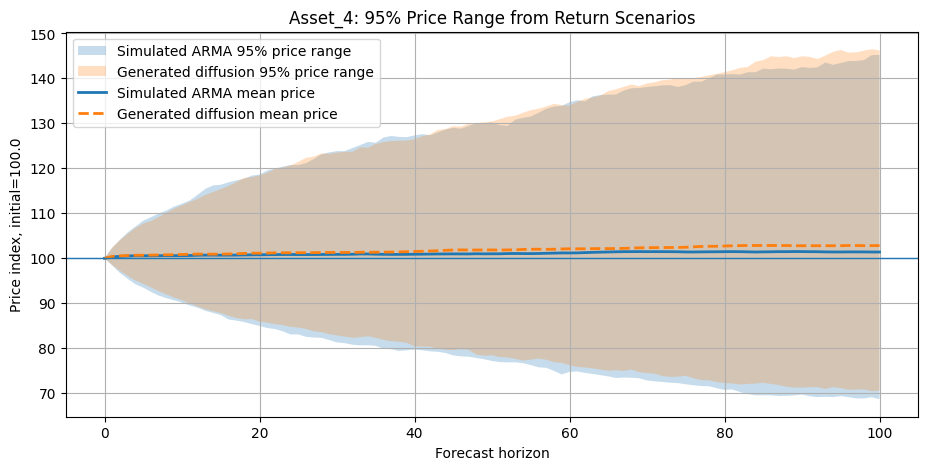

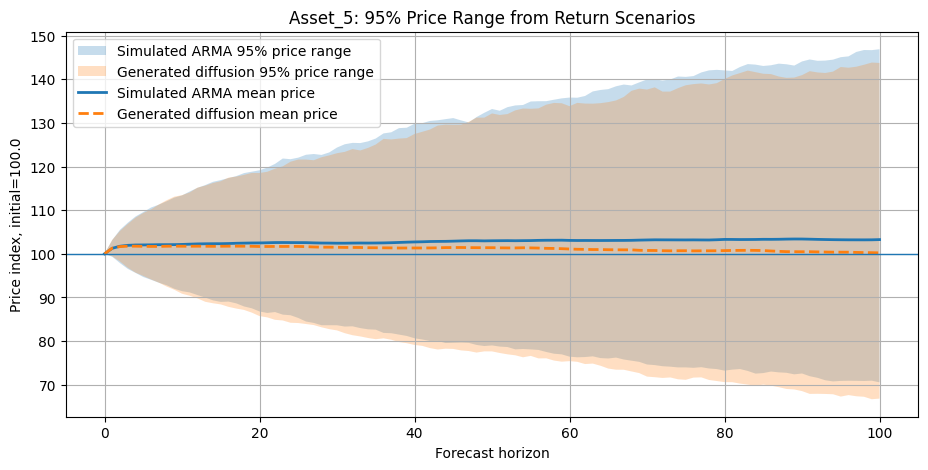

In [32]:
# Convert generated standardized returns back to raw returns
generated_raw = (
    generated_std * std_vec.reshape(1, 1, -1)
    + mean_vec.reshape(1, 1, -1)
)

price_band_results = plot_95_price_bands(
    generated_returns=generated_raw,
    simulated_returns=simulated_raw,
    asset_names=asset_names,
    initial_price=100.0,
    scale_name="raw returns",
)